LIBRARIES

In [ ]:
!pip show torch
!pip install rdkit
!pip install torch_geometric
!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 20.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.6 MB/s eta 0:00:00
Looking in links: https://

In [ ]:
import pickle
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch_geometric.nn import GCNConv,global_mean_pool, BatchNorm
from torch_geometric.data import Data
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
project_path = '/content/drive/My Drive/Colab Notebook'
os.chdir(project_path)

Mounted at /content/drive


In [ ]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [ ]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [ ]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

In [ ]:
def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))
        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │     0.090│     1.517│     0.058
  C  │  6   │     0.045│    -0.013│     0.064
  C  │  6   │     0.931│    -0.570│     1.193
  O  │  8   │    -1.313│    -0.364│     0.282
  C  │  6   │     0.502│    -0.548│    -1.317
  C  │  6   │     0.391│    -2.063│    -1.443
  N  │  7   │     1.313│    -2.658│    -2.244
  O  │  8   │    -0.479│    -2.716│    -0.879
  H  │  1   │     1.110│     1.887│    -0.093
  H  │  1   │    -0.550│     1.915│    -0.735
  H  │  1   │    -0.279│     1.899│     1.014
  H  │  1   │     0.583│    -0.182│     2.154
  H  │  1   │     0.874│    -1.661│     1.230
  H  │  1   │     1.980│    -0.281│     1.064
  H  │  1   │    -1.372│    -1.316│     0.096
  H  │  1   │    -0.154│    -0.115│    -2.082
  H  │  1   │     1.524│    -0.220│    -1.540
  H  │  1   │     2.022│    -2.135│    -2.728
  H  │  1   │     1.242│    -3.650│    -2.404


SMILE: CC(C)(O)CC(N)=O


Formati

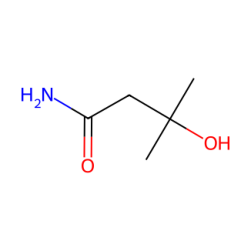

In [ ]:

# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

TASK 1: SMILES

STEP1: Tokenize the molecules : Since SMILE representation is a string of characters, numbers, bonds, brackets etc, the first thought that comes to mind is to tokenize it character after character. But you're treating every character equally, even ones that form known substructures like 'C(=O)O' (carboxylic acid) or 'Cl' (chlorine). But the idea that there would be sub-strings repeated across molecules, similar to sub-structures found in words as shown by researches.  

What I found is: Using a pretrained model, existing in python. When researched on what are pre-trained models: they are "just like we train a model to learn weights, we train a tokenizer to learn which chunks are most meaningful".

In [ ]:
!wget https://raw.githubusercontent.com/XinhaoLi74/SmilesPE/master/SPE_ChEMBL.txt

--2025-06-19 07:17:09--  https://raw.githubusercontent.com/XinhaoLi74/SmilesPE/master/SPE_ChEMBL.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27879 (27K) [text/plain]
Saving to: ‘SPE_ChEMBL.txt.1’

SPE_ChEMBL.txt.1    100%[===================>]  27.23K  --.-KB/s    in 0.001s  

2025-06-19 07:17:10 (18.2 MB/s) - ‘SPE_ChEMBL.txt.1’ saved [27879/27879]



In [ ]:
!pip install SmilesPE

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 25.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 re

Shifting the batch process here as we would have to tokenize it.

In [ ]:
train_smile_data = [smiles_data[i] for i in train_idxes]
test_smile_data = [smiles_data[i] for i in test_idxes]
train_fe = [fe[i] for i in train_idxes]
test_fe  = [fe[i] for i in test_idxes]



SPE tokenizer is popular since it tokenizes sub structures and is aware of more properties. The vocabulary is highly efficient since it has been pretrained on CHemNet dataset I suppose which is a big deal in chemistry. So, we will use SPE_tokenizer but SPE tokenizer does not reveal its vocab. So we have to manually create it seems. And then initialize a tokenizer. But kep points are to introduce UNKNOWN because I am using SPE_TOKENIZER and test model have have tokens which this tokenizer had never seen. so we have to give it as UNK. Similarly, we need to introduce PAD, so that we add extra tokens to shorter token sequence lengths.

In [ ]:
import codecs
from SmilesPE.tokenizer import SPE_Tokenizer

spe_vocab = codecs.open("SPE_ChEMBL.txt",'r')
tokenizer = SPE_Tokenizer(spe_vocab)
with codecs.open("SPE_ChEMBL.txt", "r") as vocab_file:
    vocab_lines = vocab_file.readlines()
vocab_list = [line.strip() for line in vocab_lines]
special_tokens = ['[PAD]','[UNK]']
vocab_list = special_tokens + vocab_list
token_to_index = {token: idx for idx, token in enumerate(vocab_list)}

In [ ]:
print('[PAD]' in vocab_list)

True


In [ ]:
print("First SMILES:", smiles_data[0])
print("Tokens:", tokenizer.tokenize(smiles_data[0]))
print("First 10 vocab tokens:", vocab_list[:10])

First SMILES: C
Tokens: C
First 10 vocab tokens: ['[PAD]', '[UNK]', 'c c', 'C C', 'O )', 'c 1', 'c (', 'C (', '= O)', 'c 2']


 STEP 1: create tokens. STEP 2: we need index for those tokens.

In [ ]:
embedding   = []
train_tokenized = [tokenizer.tokenize(smi) for smi in train_smile_data]
test_tokenized = [tokenizer.tokenize(smi) for smi in test_smile_data]
UNK_INDEX = token_to_index.get('[UNK]',0)
PAD_INDEX = token_to_index.get('[PAD]',0)
train_token_id = [
    [token_to_index.get(token,UNK_INDEX) for token in tokens]
    for tokens in train_tokenized]
test_token_id = [
    [token_to_index.get(token,UNK_INDEX) for token in tokens]
    for tokens in test_tokenized]

While converting idexes to tensor, if we directly try then it fails because tokens are of varying lengths and thus, we need to pad.

In [ ]:
embed = nn.Embedding(num_embeddings = len(vocab_list) ,embedding_dim=16,padding_idx=PAD_INDEX)

train_tensor = [torch.tensor(i,dtype=torch.long) for i in train_token_id]
test_tensor = [torch.tensor(i,dtype=torch.long) for i in test_token_id]
train_label_tensor = [torch.tensor(i,dtype=torch.float) for i in train_fe]
test_label_tensor = [torch.tensor(i,dtype=torch.float) for i in test_fe]

padded_train_tensor = pad_sequence(train_tensor,batch_first=True,padding_value=0)
padded_test_tensor = pad_sequence(test_tensor,batch_first=True,padding_value=0)
#embedded_train_tokens = embed(padded_train_tensor)
#embedded_test_tokens = embed(padded_test_tensor)
print(len(padded_train_tensor[0]))

74


MODEL: The basic idea is inspired by the paper where the authors compare GRU,LSTM and CNN-GRU models for SMILE. They get good results for CNN-GRU and so, I am developing this model from scratch for the SMILE representation. It consists of pretty obvious layers as can be observed but we need to be careful about the sizes that these models require their inputs to be. Otherwise pretty straightforward. CNN->GRU-> FC. A point to note is these GRU are bidirectional which means it learns the seqence of text from forward to backwards and backward to forward. And num_layers=2 means they are stacked GRU. These are used in the paper.

In [ ]:
class smiles_CGRU(nn.Module):
  def __init__(self,vocab_size,emb_dim,hidden_units,dropout):
    super().__init__()
    self.embed = nn.Embedding(vocab_size,emb_dim)
    self.cnn  = nn.Conv1d(in_channels=emb_dim,out_channels=192,kernel_size=3)
    self.gru  = nn.GRU(input_size=192,hidden_size=hidden_units,num_layers=2,batch_first=True,bidirectional=True,dropout=dropout)
    self.fc   = nn.Linear(hidden_units*2,1)

  def forward(self,inp):
     x = self.embed(inp)
     x = x.transpose(1,2)
     x = self.cnn(x)
     x = F.relu(x)

     x = x.transpose(1,2)
     output,hidden = self.gru(x)
     x=output.mean(dim=1)
     x = self.fc(x)
     return x


Prepare training and testing function : same as geometric representation

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train(model,train_loader,optimizer,loss_fn):
  model.train()
  total_loss =0
  for input,target in train_loader:
    input = input.to(device)
    target = target.to(device)
    optimizer.zero_grad() # dont store the gradients
    out = model(input)
    loss = loss_fn(out.squeeze(-1),target.squeeze(-1))
    loss.backward()
    optimizer.step()
    total_loss += loss.item()*input.size(0) #item converts loss into python since total_loss is python variable
  return total_loss/len(train_loader.dataset)

def test(model,test_loader,loss_fn):
  model.eval()
  total_loss =0
  preds = []
  ground_truth = []
  with torch.no_grad():
    for input,target in test_loader:
      input=input.to(device)
      target = target.to(device)
      out = model(input)
      loss = loss_fn(out.squeeze(-1),target.squeeze(-1))
      total_loss += loss.item()*input.size(0)

      preds.append(out.detach().cpu())
      ground_truth.append(target.detach().cpu())

  preds = torch.cat(preds)
  ground_truth = torch.cat(ground_truth)
  preds = preds.cpu().numpy().reshape(-1, 1)
  ground_truth = ground_truth.cpu().numpy().reshape(-1, 1)

  return total_loss/len(test_loader.dataset),preds,ground_truth

Batch the data : First extract training and test data using the indexes provided. Similarly extract formation energy information. Prepare batches.

In [ ]:
train_dataset = list(zip(padded_train_tensor,train_label_tensor))
test_dataset = list(zip(padded_test_tensor,test_label_tensor))

In [ ]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True)

In [ ]:
class EarlyStopping: #Chatgpt
    def __init__(self, patience=5, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            #if self.verbose:
            #    print(f" New best loss: {val_loss:.4f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"No improvement. Patience {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


Model characteristics : The paper uses MSE loss and also another advance loss function but thats for mask. I started with MSE but there was overfitting nd very poor performance. And so i shifted to L1Loss. SmoothL1loss also doesnot work well.

In [ ]:
#loss_fn = nn.MSELoss()
loss_fn = nn.L1Loss()
model = smiles_CGRU(vocab_size=len(vocab_list),emb_dim=50,hidden_units=224,dropout=0.5).to(device)
#optimizer = torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-3,eps=1e-8)
optimizer = torch.optim.RMSprop(model.parameters(),lr=1e-3,alpha=0.9,eps=1e-8)

early_stopping = EarlyStopping(patience=4,verbose=True)
for epoch in range(1,25):
  train_loss = train(model,train_loader,optimizer,loss_fn)
  test_loss,preds,true = test(model,test_loader,loss_fn)
  print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

  early_stopping(test_loss,model)
  if early_stopping.early_stop:
    print(f"\n Early stoppign at epoch {epoch}. Best test loss achieved is {early_stopping.best_loss}")
    break

model.load_state_dict(early_stopping.best_model_state)

Epoch 01 | Train Loss: 0.7788 | Test Loss: 0.7668
Epoch 02 | Train Loss: 0.7683 | Test Loss: 0.7992
No improvement. Patience 1/4
Epoch 03 | Train Loss: 0.7677 | Test Loss: 0.7641
Epoch 04 | Train Loss: 0.7646 | Test Loss: 0.7613
Epoch 05 | Train Loss: 0.7648 | Test Loss: 0.7662
No improvement. Patience 1/4
Epoch 06 | Train Loss: 0.7635 | Test Loss: 0.7613
Epoch 07 | Train Loss: 0.7637 | Test Loss: 0.7711
No improvement. Patience 1/4
Epoch 08 | Train Loss: 0.7642 | Test Loss: 0.7686
No improvement. Patience 2/4
Epoch 09 | Train Loss: 0.7634 | Test Loss: 0.7621
No improvement. Patience 3/4
Epoch 10 | Train Loss: 0.7632 | Test Loss: 0.7637
No improvement. Patience 4/4

 Early stoppign at epoch 10. Best test loss achieved is 0.7612922934532166


<All keys matched successfully>

In [ ]:
num_unk_train = (padded_train_tensor == UNK_INDEX).sum().item()
num_unk_test  = (padded_test_tensor== UNK_INDEX).sum().item()
print(num_unk_train)
print(num_unk_test)

3339370
279939


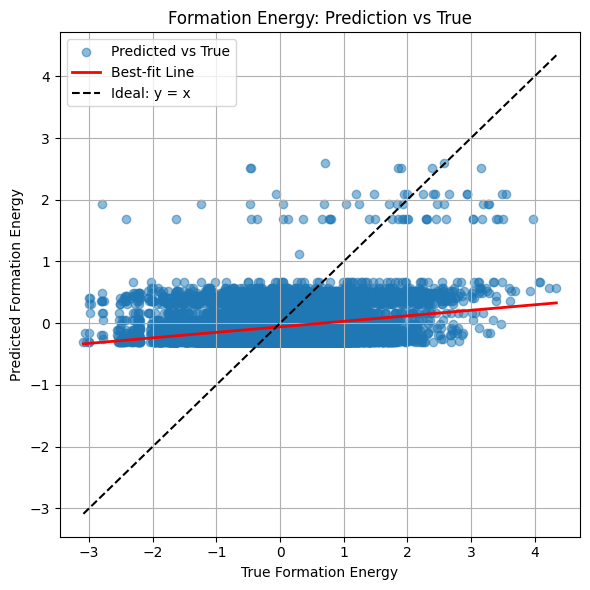

In [ ]:
# Ensure numpy arrays
from sklearn.linear_model import LinearRegression
trues_np = np.array(true).reshape(-1, 1)
preds_np = np.array(preds).reshape(-1, 1)

# Fit linear regression
reg = LinearRegression().fit(trues_np, preds_np)
line_x = np.linspace(trues_np.min(), trues_np.max(), 100).reshape(-1, 1)
line_y = reg.predict(line_x)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(trues_np, preds_np, alpha=0.5, label='Predicted vs True')
plt.plot(line_x, line_y, color='red', linewidth=2, label='Best-fit Line')
plt.plot(line_x, line_x, color='black', linestyle='--', label='Ideal: y = x')
plt.xlabel('True Formation Energy')
plt.ylabel('Predicted Formation Energy')
plt.title('Formation Energy: Prediction vs True')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
#r2 = r2_score(trues, preds)
#mae = mean_absolute_error(trues, preds)
#print(r2)
#print(mae)

# Denormalize
trues_denorm = np.array(true) * std + mu
preds_denorm = np.array(preds) * std + mu

# Compute metrics in original units
r2 = r2_score(trues_denorm, preds_denorm)
mae = mean_absolute_error(trues_denorm, preds_denorm)
mse = mean_squared_error(trues_denorm,preds_denorm)

print(f"R² score: {r2:.4f}")
print(f"MAE (eV): {mae:.4f}")
print(f"MSE (eV): {mse:.4f}")

R² score: 0.0707
MAE (eV): 7.8749
MSE (eV): 99.7546


In [ ]:
import numpy as np
print("Std. dev of ground truth:", np.std(true))
print("Std. dev of predictions: ", np.std(preds))

Std. dev of ground truth: 1.0048172
Std. dev of predictions:  0.32330623


In [ ]:
from scipy.stats import pearsonr

r, _ = pearsonr(trues_denorm.squeeze(), preds_denorm.squeeze())
print(f"Pearson r: {r:.4f}")

Pearson r: 0.2778
